In [1]:
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")

from nRTD.rtd_fitting import RTDModule, RTDDataModule

import matplotlib.pyplot as plt
import matplotlib as mpl
import ICIW_Plots
import ICIW_Plots.colors
import numpy as np
from pathlib import Path

plt.style.use(["ICIWstyle"])
plt.rcParams.update(
    {
        "font.size": 7,
    }
)

In [2]:
# givens
t_out = (0.0, 120.0)
n_out = int(4 * (t_out[1] - t_out[0]) + 1)
delta_t_out = (t_out[1] - t_out[0]) / (n_out - 1)

# the capillary times
# FBA_18032025_300ml-min_Analytik_MS
switching_periods = np.array(
    [
        5 * 60 + 0.03,
        5 * 60 + 0.27,
        5 * 60 + 0.27,
        5 * 60 + 0.28,
        5 * 60 + 0.18,
        5 * 60 + 0.26,
        5 * 60 + 0.33,
        5 * 60 + 0.27,
        5 * 60 + 0.18,
        5 * 60 + 0.05,
    ]
)
switching_times_cap = np.flip(np.cumsum(-switching_periods))
switching_times_cap = (
    np.append(switching_times_cap, 0) - 1
)  # leave enough time for the step

# the piping times
t_halfperiod = t_out[1] - t_out[0]

automated_switching_times = np.full((20,), t_halfperiod)
switching_times_reac_inlet_cold = np.insert(automated_switching_times, 0, 7.4 - 1.0)
switching_times_reac_inlet_cold = np.cumsum(switching_times_reac_inlet_cold)
switching_times_reac_outlet_cold = np.insert(automated_switching_times, 0, 7.5 - 1.0)
switching_times_reac_outlet_cold = np.cumsum(switching_times_reac_outlet_cold)
switching_times_reac_outlet_hot = np.insert(automated_switching_times, 0, 8.8 - 1.0)
switching_times_reac_outlet_hot = np.cumsum(switching_times_reac_outlet_hot)

switching_times_total_system_cold = np.insert(automated_switching_times, 0, 7.7 - 1.0)
switching_times_total_system_cold = np.cumsum(switching_times_total_system_cold)
switching_times_total_system_hot = np.insert(automated_switching_times, 0, 12.9 - 1.0)
switching_times_total_system_hot = np.cumsum(switching_times_total_system_hot)

t_kernels = [
    (0.0, 30.0),  # piping to reactor inlet
    (0.0, 40.0),  # reactor
    (0.0, 15.0),  # piping after reactor outlet
    (0.0, 30.0),  # capillary
]

n_kernels = list(
    map(
        lambda t_kernel: int(((t_kernel[1] - t_kernel[0]) / delta_t_out) + 1), t_kernels
    )
)

t_in = (0, t_out[1] - sum([t_kernel[1] for t_kernel in t_kernels]))
n_in = int(((t_in[1] - t_in[0]) / delta_t_out) + 1)

In [3]:
# the capillary times
# FBA_18032025_300ml-min_Analytik_MS
data_cap = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_001\data\FBA-E-18032025_300ml-min_Analytik_MS.npz"
    ),
    switching_times=switching_times_cap,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=1.0,
)
data_cap.setup("eval")
data_cap.y_hat = (data_cap.y - data_cap.x[:, :, [0]]) / (
    data_cap.x[:, :, [-1]] - data_cap.x[:, :, [0]]
)

In [4]:
data_reac_inlet_cold = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_002\data\MGA-E-11032025_30ml-min_1atm_ReactorInlet_MS.npz"
    ),
    switching_times=switching_times_reac_inlet_cold,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=1.0,
)

data_reac_inlet_cold.setup("eval")
data_reac_inlet_cold.y_hat = (
    data_reac_inlet_cold.y - data_reac_inlet_cold.x[:, :, [0]]
) / (data_reac_inlet_cold.x[:, :, [-1]] - data_reac_inlet_cold.x[:, :, [0]])

In [5]:
data_reac_outlet_cold = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_003\data\MGA-E-11032025_30ml-min_1atm_ReactorOutlet_MS.npz"
    ),
    switching_times=switching_times_reac_outlet_cold,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=1.0,
)
data_reac_outlet_cold.setup("eval")
data_reac_outlet_cold.y_hat = (
    data_reac_outlet_cold.y - data_reac_outlet_cold.x[:, :, [0]]
) / (data_reac_outlet_cold.x[:, :, [-1]] - data_reac_outlet_cold.x[:, :, [0]])

In [6]:
data_reac_outlet_hot = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_003\data\MGA-E-13032025_30ml-min_1atm_heated_ReactorOutlet.npz"
    ),
    switching_times=switching_times_reac_outlet_hot,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=1.0,
)
data_reac_outlet_hot.setup("eval")
data_reac_outlet_hot.y_hat = (
    data_reac_outlet_hot.y - data_reac_outlet_hot.x[:, :, [0]]
) / (data_reac_outlet_hot.x[:, :, [-1]] - data_reac_outlet_hot.x[:, :, [0]])

In [7]:
data_total_system_cold = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\data\MGA-E-10032025_120ml-min_4bar_TotalSystem.npz"
    ),
    switching_times=switching_times_total_system_cold,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=1.0,
)
data_total_system_cold.setup("eval")
data_total_system_cold.y_hat = (
    data_total_system_cold.y - data_total_system_cold.x[:, :, [0]]
) / (data_total_system_cold.x[:, :, [-1]] - data_total_system_cold.x[:, :, [0]])

In [8]:
data_total_system_hot = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\data\MGA-E-14032025_120ml-min_4bar_heated_TotalSystem.npz"
    ),
    switching_times=switching_times_total_system_hot,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=1.0,
)
data_total_system_hot.setup("eval")
data_total_system_hot.y_hat = (
    data_total_system_hot.y - data_total_system_hot.x[:, :, [0]]
) / (data_total_system_hot.x[:, :, [-1]] - data_total_system_hot.x[:, :, [0]])

In [9]:
data_dict = {
    "A": (data_cap, data_cap),
    "B": (data_reac_inlet_cold, data_reac_inlet_cold),
    "C": (data_reac_outlet_cold, data_reac_outlet_hot),
    "D": (data_total_system_cold, data_total_system_hot),
}

In [10]:
greencycler = ICIW_Plots.colors.adjacent_cycler(
    mpl.colors.to_rgb(mpl.colors.CSS4_COLORS["green"]), n=4, phi=60
)
redcycler = ICIW_Plots.colors.adjacent_cycler(
    mpl.colors.to_rgb(mpl.colors.CSS4_COLORS["brown"]), n=4, phi=45
)

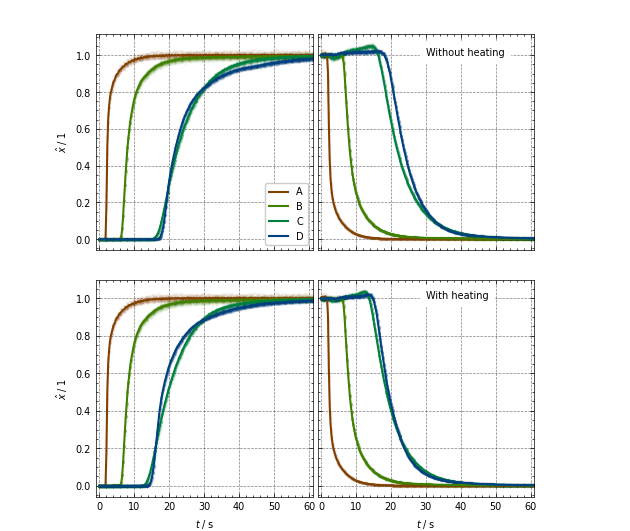

In [11]:
fig = ICIW_Plots.figure(layout="double_column", height=13.5 * ICIW_Plots.cm2inch)
with plt.rc_context({"axes.prop_cycle": greencycler}):
    axs = ICIW_Plots.make_square_subplots(
        fig,
        ax_width=5.5 * ICIW_Plots.cm2inch,
        ax_layout=(2, 2),
        sharex=True,
        sharey=True,
        sharelabel=True,
        v_sep=0.3,
        xlabel=r"$t \;/\; \mathrm{s}$",
        ylabel=r"$\hat{x} \;/\; 1$",
        xlim=(-1, 61),
    )

for key, (data_cold, data_hot) in data_dict.items():
    axs[0, 0].scatter(
        data_cold.t_out[::4, ...],
        data_cold.y_hat[::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[0, 0].plot(
        data_cold.t_out[::4, ...].mean(axis=0),
        data_cold.y_hat[::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[0, 1].scatter(
        data_cold.t_out[2::4, ...],
        1 - data_cold.y_hat[2::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[0, 1].plot(
        data_cold.t_out[2::4, ...].mean(axis=0),
        1 - data_cold.y_hat[2::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[1, 0].scatter(
        data_hot.t_out[::4, ...],
        data_hot.y_hat[::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[1, 0].plot(
        data_hot.t_out[::4, ...].mean(axis=0),
        data_hot.y_hat[::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[1, 1].scatter(
        data_hot.t_out[2::4, ...],
        1 - data_hot.y_hat[2::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[1, 1].plot(
        data_hot.t_out[2::4, ...].mean(axis=0),
        1 - data_hot.y_hat[2::4, 0, :].mean(axis=0),
        label=key,
    )
axs[0, 0].legend()
axs[0, 1].text(x=30, y=1, s="Without heating", backgroundcolor="white")
axs[1, 1].text(x=30, y=1, s="With heating", backgroundcolor="white")

plt.savefig("exp_data_4bar_Ar.png", dpi=600)

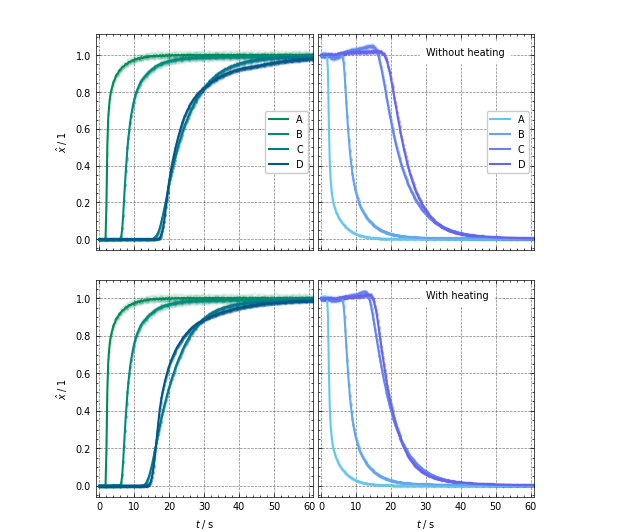

In [12]:
fig = ICIW_Plots.figure(layout="double_column", height=13.5 * ICIW_Plots.cm2inch)
axs = ICIW_Plots.make_square_subplots(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    ax_layout=(2, 2),
    sharex=True,
    sharey=True,
    sharelabel=True,
    v_sep=0.3,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$\hat{x} \;/\; 1$",
    xlim=(-1, 61),
)
darkcyancycler = ICIW_Plots.colors.adjacent_cycler(
    mpl.colors.to_rgb(mpl.colors.CSS4_COLORS["darkcyan"]), n=4, phi=15
)
firebrickcycler = ICIW_Plots.colors.adjacent_cycler(
    mpl.colors.to_rgb(mpl.colors.CSS4_COLORS["cornflowerblue"]), n=4, phi=15
)
axs[0, 0].set_prop_cycle(darkcyancycler)
axs[1, 0].set_prop_cycle(darkcyancycler)
axs[0, 1].set_prop_cycle(firebrickcycler)
axs[1, 1].set_prop_cycle(firebrickcycler)

for key, (data_cold, data_hot) in data_dict.items():
    axs[0, 0].scatter(
        data_cold.t_out[::4, ...],
        data_cold.y_hat[::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[0, 0].plot(
        data_cold.t_out[::4, ...].mean(axis=0),
        data_cold.y_hat[::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[0, 1].scatter(
        data_cold.t_out[2::4, ...],
        1 - data_cold.y_hat[2::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[0, 1].plot(
        data_cold.t_out[2::4, ...].mean(axis=0),
        1 - data_cold.y_hat[2::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[1, 0].scatter(
        data_hot.t_out[::4, ...],
        data_hot.y_hat[::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[1, 0].plot(
        data_hot.t_out[::4, ...].mean(axis=0),
        data_hot.y_hat[::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[1, 1].scatter(
        data_hot.t_out[2::4, ...],
        1 - data_hot.y_hat[2::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[1, 1].plot(
        data_hot.t_out[2::4, ...].mean(axis=0),
        1 - data_hot.y_hat[2::4, 0, :].mean(axis=0),
        label=key,
    )
axs[0, 0].legend(loc="center right")
axs[0, 1].legend(loc="center right")
axs[0, 1].text(x=30, y=1, s="Without heating", backgroundcolor="white")
axs[1, 1].text(x=30, y=1, s="With heating", backgroundcolor="white")

plt.savefig("exp_data_4bar_Ar.png", dpi=600)

Text(30, 1, 'With heating')

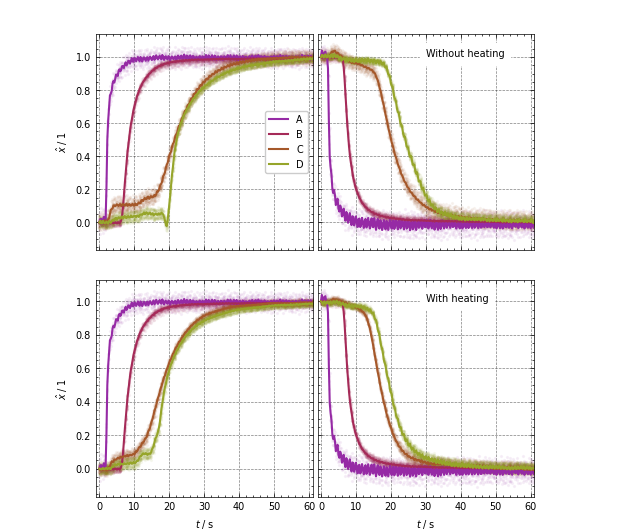

In [13]:
fig = ICIW_Plots.figure(layout="double_column", height=13.5 * ICIW_Plots.cm2inch)
with plt.rc_context({"axes.prop_cycle": redcycler}):
    axs = ICIW_Plots.make_square_subplots(
        fig,
        ax_width=5.5 * ICIW_Plots.cm2inch,
        ax_layout=(2, 2),
        sharex=True,
        sharey=True,
        sharelabel=True,
        v_sep=0.3,
        xlabel=r"$t \;/\; \mathrm{s}$",
        ylabel=r"$\hat{x} \;/\; 1$",
        xlim=(-1, 61),
    )

for key, (data_cold, data_hot) in data_dict.items():
    axs[0, 0].scatter(
        data_cold.t_out[1::4, ...],
        data_cold.y_hat[1::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[0, 0].plot(
        data_cold.t_out[1::4, ...].mean(axis=0),
        data_cold.y_hat[1::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[0, 1].scatter(
        data_cold.t_out[3::4, ...],
        1 - data_cold.y_hat[3::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[0, 1].plot(
        data_cold.t_out[3::4, ...].mean(axis=0),
        1 - data_cold.y_hat[3::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[1, 0].scatter(
        data_hot.t_out[1::4, ...],
        data_hot.y_hat[1::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[1, 0].plot(
        data_hot.t_out[1::4, ...].mean(axis=0),
        data_hot.y_hat[1::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[1, 1].scatter(
        data_hot.t_out[3::4, ...],
        1 - data_hot.y_hat[3::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[1, 1].plot(
        data_hot.t_out[3::4, ...].mean(axis=0),
        1 - data_hot.y_hat[3::4, 0, :].mean(axis=0),
        label=key,
    )
axs[0, 0].legend(loc="center right")
axs[0, 1].text(x=30, y=1, s="Without heating", backgroundcolor="white")
axs[1, 1].text(x=30, y=1, s="With heating", backgroundcolor="white")

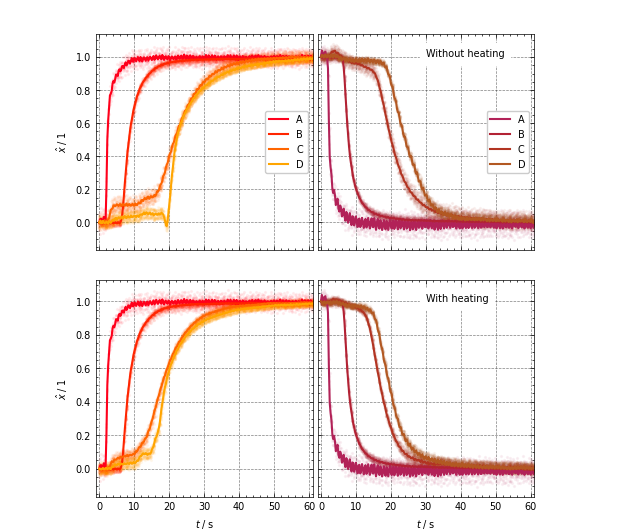

In [14]:
fig = ICIW_Plots.figure(layout="double_column", height=13.5 * ICIW_Plots.cm2inch)

axs = ICIW_Plots.make_square_subplots(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    ax_layout=(2, 2),
    sharex=True,
    sharey=True,
    sharelabel=True,
    v_sep=0.3,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$\hat{x} \;/\; 1$",
    xlim=(-1, 61),
)

firebrickcycler = ICIW_Plots.colors.adjacent_cycler(
    mpl.colors.to_rgb(mpl.colors.CSS4_COLORS["firebrick"]), n=4, phi=15
)
orangeredcycler = ICIW_Plots.colors.adjacent_cycler(
    mpl.colors.to_rgb(mpl.colors.CSS4_COLORS["orangered"]), n=4, phi=15
)
axs[0, 0].set_prop_cycle(orangeredcycler)
axs[1, 0].set_prop_cycle(orangeredcycler)
axs[0, 1].set_prop_cycle(firebrickcycler)
axs[1, 1].set_prop_cycle(firebrickcycler)

for key, (data_cold, data_hot) in data_dict.items():
    axs[0, 0].scatter(
        data_cold.t_out[1::4, ...],
        data_cold.y_hat[1::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[0, 0].plot(
        data_cold.t_out[1::4, ...].mean(axis=0),
        data_cold.y_hat[1::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[0, 1].scatter(
        data_cold.t_out[3::4, ...],
        1 - data_cold.y_hat[3::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[0, 1].plot(
        data_cold.t_out[3::4, ...].mean(axis=0),
        1 - data_cold.y_hat[3::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[1, 0].scatter(
        data_hot.t_out[1::4, ...],
        data_hot.y_hat[1::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[1, 0].plot(
        data_hot.t_out[1::4, ...].mean(axis=0),
        data_hot.y_hat[1::4, 0, :].mean(axis=0),
        label=key,
    )
    axs[1, 1].scatter(
        data_hot.t_out[3::4, ...],
        1 - data_hot.y_hat[3::4, ...],
        alpha=0.05,
        s=2,
    )
    axs[1, 1].plot(
        data_hot.t_out[3::4, ...].mean(axis=0),
        1 - data_hot.y_hat[3::4, 0, :].mean(axis=0),
        label=key,
    )
axs[0, 0].legend(loc="center right")
axs[0, 1].legend(loc="center right")
axs[0, 1].text(x=30, y=1, s="Without heating", backgroundcolor="white")
axs[1, 1].text(x=30, y=1, s="With heating", backgroundcolor="white")

plt.savefig("exp_data_4bar_He.png", dpi=600)

In [15]:
ICIW_Plots.size("ICIW", "single_column", "cm")

7.5

In [16]:
ICIW_Plots

<module 'ICIW_Plots' from 'c:\\ProgramData\\Anaconda3\\envs\\ML3\\Lib\\site-packages\\ICIW_Plots\\__init__.py'>